<a href="https://colab.research.google.com/github/MunagotiAparna/BusBooking/blob/main/Week_4_Language_Trends_NLP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import nltk

from collections import Counter

In [39]:
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [40]:
url = "https://raw.githubusercontent.com/justmarkham/DAT8/master/data/yelp.csv"

df = pd.read_csv(url)

print("Dataset Shape:", df.shape)
print("\nColumns:", df.columns.tolist())

df.head()

Dataset Shape: (10000, 10)

Columns: ['business_id', 'date', 'review_id', 'stars', 'text', 'type', 'user_id', 'cool', 'useful', 'funny']


,business_id,date,review_id,stars,text,type,user_id,cool,useful,funny
0,9yKzy9PApeiPPOUJEtnvkg,2011-01-26,fWKvX83p0-ka4JS3dc6E5A,5,My wife took me here on my birthday for breakf...,review,rLtl8ZkDX5vH5nAx9C3q5Q,2,5,0
1,ZRJwVLyzEJq1VAihDhYiow,2011-07-27,IjZ33sJrzXqU-0X6U8NwyA,5,I have no idea why some people give bad review...,review,0a2KyEL0d3Yb1V6aivbIuQ,0,0,0
2,6oRAC4uyJCsJl1X0WZpVSA,2012-06-14,IESLBzqUCLdSzSqm0eCSxQ,4,love the gyro plate. Rice is so good and I als...,review,0hT2KtfLiobPvh6cDC8JQg,0,1,0
3,_1QQZuf4zZOyFCvXc0o6Vg,2010-05-27,G-WvGaISbqqaMHlNnByodA,5,"Rosie, Dakota, and I LOVE Chaparral Dog Park!!...",review,uZetl9T0NcROGOyFfughhg,1,2,0
4,6ozycU1RpktNG2-1BroVtw,2012-01-05,1uJFq2r5QfJG_6ExMRCaGw,5,General Manager Scott Petello is a good egg!!!...,review,vYmM4KTsC8ZfQBg-j5MWkw,0,0,0


In [41]:
url = "https://raw.githubusercontent.com/akhilesh-reddy/News-Classification/master/RedditNews.csv"

df = pd.read_csv(url)

print("Dataset Shape:", df.shape)
print("\nColumns:", df.columns.tolist())

df.head()

HTTPError: HTTP Error 404: Not Found

In [42]:
df['text_length'] = df['text'].apply(len)
display(df.head())

,business_id,date,review_id,stars,text,type,user_id,cool,useful,funny,text_length
0,9yKzy9PApeiPPOUJEtnvkg,2011-01-26,fWKvX83p0-ka4JS3dc6E5A,5,My wife took me here on my birthday for breakf...,review,rLtl8ZkDX5vH5nAx9C3q5Q,2,5,0,889
1,ZRJwVLyzEJq1VAihDhYiow,2011-07-27,IjZ33sJrzXqU-0X6U8NwyA,5,I have no idea why some people give bad review...,review,0a2KyEL0d3Yb1V6aivbIuQ,0,0,0,1345
2,6oRAC4uyJCsJl1X0WZpVSA,2012-06-14,IESLBzqUCLdSzSqm0eCSxQ,4,love the gyro plate. Rice is so good and I als...,review,0hT2KtfLiobPvh6cDC8JQg,0,1,0,76
3,_1QQZuf4zZOyFCvXc0o6Vg,2010-05-27,G-WvGaISbqqaMHlNnByodA,5,"Rosie, Dakota, and I LOVE Chaparral Dog Park!!...",review,uZetl9T0NcROGOyFfughhg,1,2,0,419
4,6ozycU1RpktNG2-1BroVtw,2012-01-05,1uJFq2r5QfJG_6ExMRCaGw,5,General Manager Scott Petello is a good egg!!!...,review,vYmM4KTsC8ZfQBg-j5MWkw,0,0,0,469


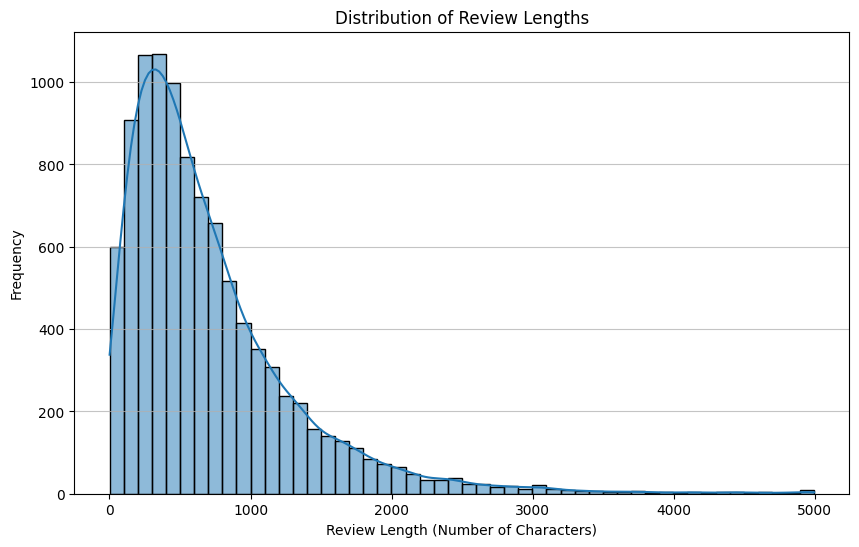

In [43]:
plt.figure(figsize=(10, 6))
sns.histplot(df['text_length'], bins=50, kde=True)
plt.title('Distribution of Review Lengths')
plt.xlabel('Review Length (Number of Characters)')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

In [46]:
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    text = str(text).lower()

    # Remove URLs, numbers and special characters
    text = re.sub(r'http\S+|www\S+|\d+', '', text) # Also remove numbers
    text = re.sub(r'[^a-z\s]', ' ', text)

    # Tokenization
    tokens = nltk.word_tokenize(text)

    # Remove stopwords and short words, then lemmatize
    tokens = [
        lemmatizer.lemmatize(word)
        for word in tokens
        if word not in stop_words and len(word) > 2
    ]

    return tokens

df['tokens'] = df['text'].apply(preprocess_text)

# Create cleaned text column
df['cleaned_text'] = df['tokens'].apply(lambda x: ' '.join(x))

print("Text preprocessing complete. Displaying the first few rows with new 'tokens' and 'cleaned_text' columns:")
display(df[['text', 'tokens', 'cleaned_text']].head())

Text preprocessing complete. Displaying the first few rows with new 'tokens' and 'cleaned_text' columns:


,text,tokens,cleaned_text
0,My wife took me here on my birthday for breakf...,"[wife, took, birthday, breakfast, excellent, w...",wife took birthday breakfast excellent weather...
1,I have no idea why some people give bad review...,"[idea, people, give, bad, review, place, go, s...",idea people give bad review place go show plea...
2,love the gyro plate. Rice is so good and I als...,"[love, gyro, plate, rice, good, also, dig, can...",love gyro plate rice good also dig candy selec...
3,"Rosie, Dakota, and I LOVE Chaparral Dog Park!!...","[rosie, dakota, love, chaparral, dog, park, co...",rosie dakota love chaparral dog park convenien...
4,General Manager Scott Petello is a good egg!!!...,"[general, manager, scott, petello, good, egg, ...",general manager scott petello good egg detail ...


In [44]:
df.columns = df.columns.str.strip()

print("Dataset Shape:", df.shape)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDataset Information:")
df.info()

Dataset Shape: (10000, 11)

Missing Values:
business_id    0
date           0
review_id      0
stars          0
text           0
type           0
user_id        0
cool           0
useful         0
funny          0
text_length    0
dtype: int64

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   business_id  10000 non-null  object
 1   date         10000 non-null  object
 2   review_id    10000 non-null  object
 3   stars        10000 non-null  int64 
 4   text         10000 non-null  object
 5   type         10000 non-null  object
 6   user_id      10000 non-null  object
 7   cool         10000 non-null  int64 
 8   useful       10000 non-null  int64 
 9   funny        10000 non-null  int64 
 10  text_length  10000 non-null  int64 
dtypes: int64(5), object(6)
memory usage: 859.5+ KB


In [48]:
print("Columns:", df.columns.tolist())
print("Shape:", df.shape)
df.head()

Columns: ['business_id', 'date', 'review_id', 'stars', 'text', 'type', 'user_id', 'cool', 'useful', 'funny', 'text_length', 'tokens', 'cleaned_text']
Shape: (10000, 13)


,business_id,date,review_id,stars,text,type,user_id,cool,useful,funny,text_length,tokens,cleaned_text
0,9yKzy9PApeiPPOUJEtnvkg,2011-01-26,fWKvX83p0-ka4JS3dc6E5A,5,My wife took me here on my birthday for breakf...,review,rLtl8ZkDX5vH5nAx9C3q5Q,2,5,0,889,"[wife, took, birthday, breakfast, excellent, w...",wife took birthday breakfast excellent weather...
1,ZRJwVLyzEJq1VAihDhYiow,2011-07-27,IjZ33sJrzXqU-0X6U8NwyA,5,I have no idea why some people give bad review...,review,0a2KyEL0d3Yb1V6aivbIuQ,0,0,0,1345,"[idea, people, give, bad, review, place, go, s...",idea people give bad review place go show plea...
2,6oRAC4uyJCsJl1X0WZpVSA,2012-06-14,IESLBzqUCLdSzSqm0eCSxQ,4,love the gyro plate. Rice is so good and I als...,review,0hT2KtfLiobPvh6cDC8JQg,0,1,0,76,"[love, gyro, plate, rice, good, also, dig, can...",love gyro plate rice good also dig candy selec...
3,_1QQZuf4zZOyFCvXc0o6Vg,2010-05-27,G-WvGaISbqqaMHlNnByodA,5,"Rosie, Dakota, and I LOVE Chaparral Dog Park!!...",review,uZetl9T0NcROGOyFfughhg,1,2,0,419,"[rosie, dakota, love, chaparral, dog, park, co...",rosie dakota love chaparral dog park convenien...
4,6ozycU1RpktNG2-1BroVtw,2012-01-05,1uJFq2r5QfJG_6ExMRCaGw,5,General Manager Scott Petello is a good egg!!!...,review,vYmM4KTsC8ZfQBg-j5MWkw,0,0,0,469,"[general, manager, scott, petello, good, egg, ...",general manager scott petello good egg detail ...


In [49]:
import pandas as pd

url = "https://raw.githubusercontent.com/selva86/datasets/master/newsgroups.json"

df = pd.read_json(url)

print("Dataset Shape:", df.shape)
print("Columns:", df.columns.tolist())
df.head()

Dataset Shape: (11314, 3)
Columns: ['content', 'target', 'target_names']


,content,target,target_names
0,From: lerxst@wam.umd.edu (where's my thing)\nS...,7,rec.autos
1,From: guykuo@carson.u.washington.edu (Guy Kuo)...,4,comp.sys.mac.hardware
2,From: twillis@ec.ecn.purdue.edu (Thomas E Will...,4,comp.sys.mac.hardware
3,From: jgreen@amber (Joe Green)\nSubject: Re: W...,1,comp.graphics
4,From: jcm@head-cfa.harvard.edu (Jonathan McDow...,14,sci.space


In [50]:
print(df.columns.tolist())
df.head()

['content', 'target', 'target_names']


,content,target,target_names
0,From: lerxst@wam.umd.edu (where's my thing)\nS...,7,rec.autos
1,From: guykuo@carson.u.washington.edu (Guy Kuo)...,4,comp.sys.mac.hardware
2,From: twillis@ec.ecn.purdue.edu (Thomas E Will...,4,comp.sys.mac.hardware
3,From: jgreen@amber (Joe Green)\nSubject: Re: W...,1,comp.graphics
4,From: jcm@head-cfa.harvard.edu (Jonathan McDow...,14,sci.space


In [52]:
import nltk
import pandas as pd
import matplotlib.pyplot as plt
import re

nltk.download('gutenberg')
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')

from nltk.corpus import gutenberg

print(gutenberg.fileids())

[nltk_data] Downloading package gutenberg to /root/nltk_data...


['austen-emma.txt', 'austen-persuasion.txt', 'austen-sense.txt', 'bible-kjv.txt', 'blake-poems.txt', 'bryant-stories.txt', 'burgess-busterbrown.txt', 'carroll-alice.txt', 'chesterton-ball.txt', 'chesterton-brown.txt', 'chesterton-thursday.txt', 'edgeworth-parents.txt', 'melville-moby_dick.txt', 'milton-paradise.txt', 'shakespeare-caesar.txt', 'shakespeare-hamlet.txt', 'shakespeare-macbeth.txt', 'whitman-leaves.txt']


[nltk_data]   Unzipping corpora/gutenberg.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [53]:
selected_books = [
    'austen-emma.txt',
    'austen-persuasion.txt',
    'austen-sense.txt',
    'melville-moby_dick.txt',
    'carroll-alice.txt'
]

data = []

for book in selected_books:
    text = gutenberg.raw(book)
    data.append({
        'Book': book,
        'Text': text
    })

df = pd.DataFrame(data)

print("Dataset Shape:", df.shape)
df[['Book']].head()

Dataset Shape: (5, 2)


,Book
0,austen-emma.txt
1,austen-persuasion.txt
2,austen-sense.txt
3,melville-moby_dick.txt
4,carroll-alice.txt


In [54]:
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', ' ', text)

    tokens = nltk.word_tokenize(text)

    tokens = [
        lemmatizer.lemmatize(word)
        for word in tokens
        if word not in stop_words and len(word) > 2
    ]

    return tokens

df['tokens'] = df['Text'].apply(preprocess_text)

df['cleaned_text'] = df['tokens'].apply(lambda x: ' '.join(x))

print(df[['Book', 'cleaned_text']].head())

                     Book                                       cleaned_text
0         austen-emma.txt  emma jane austen volume chapter emma woodhouse...
1   austen-persuasion.txt  persuasion jane austen chapter sir walter elli...
2        austen-sense.txt  sense sensibility jane austen chapter family d...
3  melville-moby_dick.txt  moby dick herman melville etymology supplied l...
4       carroll-alice.txt  alice adventure wonderland lewis carroll chapt...


In [55]:
from collections import Counter

all_words = []

for tokens in df['tokens']:
    all_words.extend(tokens)

word_freq = Counter(all_words)

top_words = word_freq.most_common(15)

print("Top 15 Most Frequent Words:")
for word, count in top_words:
    print(word, ":", count)

Top 15 Most Frequent Words:
would : 2206
could : 2159
one : 2079
said : 1820
mr : 1535
whale : 1494
must : 1409
time : 1259
much : 1255
every : 1158
thing : 1134
like : 1111
well : 1101
little : 1074
man : 1023


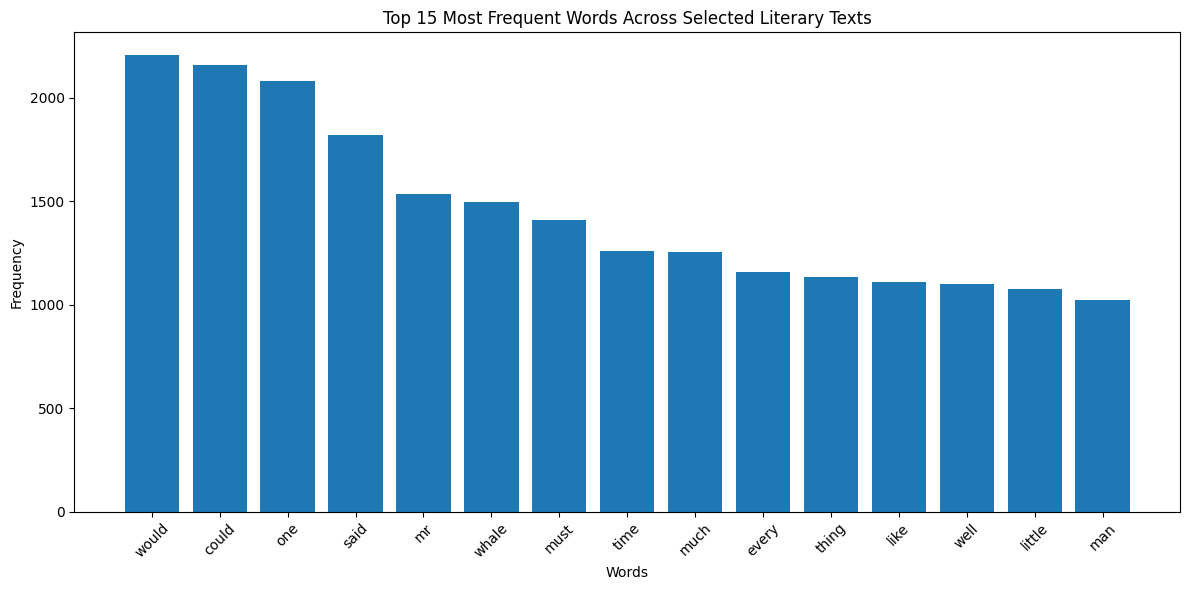

In [56]:
words = [word for word, count in top_words]
counts = [count for word, count in top_words]

plt.figure(figsize=(12, 6))
plt.bar(words, counts)
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.title("Top 15 Most Frequent Words Across Selected Literary Texts")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [57]:
keywords = ['love', 'life', 'man', 'time']

trend_data = pd.DataFrame()

for keyword in keywords:
    trend_data[keyword] = df['tokens'].apply(
        lambda tokens: tokens.count(keyword)
    )

trend_data['Book'] = df['Book']

trend_data

,love,life,man,time,Book
0,126,87,236,309,austen-emma.txt
1,44,57,134,168,austen-persuasion.txt
2,82,66,121,259,austen-sense.txt
3,25,196,527,446,melville-moby_dick.txt
4,3,16,5,77,carroll-alice.txt


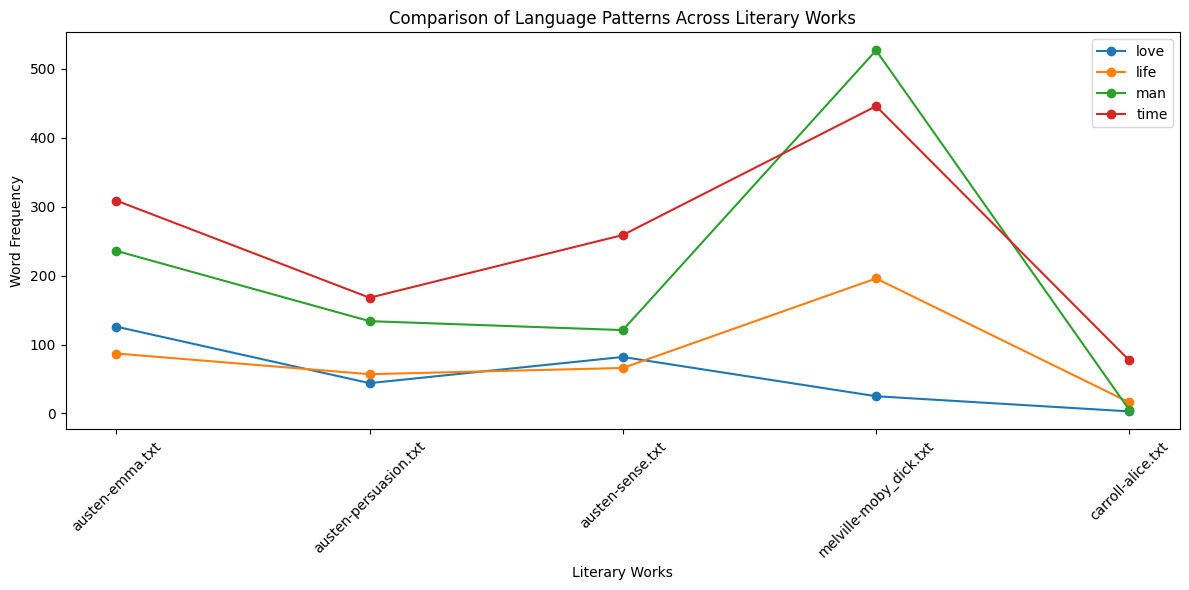

In [58]:
plt.figure(figsize=(12, 6))

x = range(len(df))

for keyword in keywords:
    plt.plot(x, trend_data[keyword], marker='o', label=keyword)

plt.xticks(x, df['Book'], rotation=45)
plt.xlabel("Literary Works")
plt.ylabel("Word Frequency")
plt.title("Comparison of Language Patterns Across Literary Works")
plt.legend()
plt.tight_layout()
plt.show()

In [59]:
!pip -q install gensim

from gensim import corpora
from gensim.models import LdaModel

dictionary = corpora.Dictionary(df['tokens'])
dictionary.filter_extremes(no_below=1, no_above=0.8)

corpus = [dictionary.doc2bow(tokens) for tokens in df['tokens']]

lda_model = LdaModel(
    corpus=corpus,
    id2word=dictionary,
    num_topics=3,
    random_state=42,
    passes=15
)

for idx, topic in lda_model.print_topics(num_words=10):
    print(f"\nTopic {idx + 1}: {topic}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.8/27.8 MB 50.0 MB/s eta 0:00:00

Topic 1: 0.022*"whale" + 0.009*"ship" + 0.008*"sea" + 0.007*"ahab" + 0.007*"boat" + 0.005*"captain" + 0.004*"thou" + 0.004*"stubb" + 0.004*"queequeg" + 0.004*"sperm"

Topic 2: 0.043*"alice" + 0.007*"king" + 0.007*"turtle" + 0.006*"hatter" + 0.006*"mock" + 0.006*"gryphon" + 0.006*"rabbit" + 0.005*"cat" + 0.005*"mouse" + 0.005*"duchess"

Topic 3: 0.022*"mr" + 0.012*"emma" + 0.010*"elinor" + 0.008*"marianne" + 0.007*"anne" + 0.007*"harriet" + 0.006*"weston" + 0.006*"knightley" + 0.005*"elton" + 0.005*"mother"


In [60]:
chunk_size = 500  # words per document chunk

documents = []

for book in selected_books:
    tokens = df.loc[df['Book'] == book, 'tokens'].iloc[0]

    for i in range(0, len(tokens), chunk_size):
        chunk = tokens[i:i + chunk_size]

        if len(chunk) > 100:
            documents.append({
                'Book': book,
                'tokens': chunk
            })

chunks_df = pd.DataFrame(documents)

print("Number of text chunks:", len(chunks_df))
chunks_df.head()

Number of text chunks: 569


,Book,tokens
0,austen-emma.txt,"[emma, jane, austen, volume, chapter, emma, wo..."
1,austen-emma.txt,"[would, great, deal, happier, spent, rest, lif..."
2,austen-emma.txt,"[look, tear, hardly, long, face, seen, felt, g..."
3,austen-emma.txt,"[generation, rising, gentility, property, rece..."
4,austen-emma.txt,"[received, suppose, heard, handsome, letter, f..."


In [61]:
from gensim import corpora
from gensim.models import LdaModel

dictionary = corpora.Dictionary(chunks_df['tokens'])
dictionary.filter_extremes(no_below=2, no_above=0.7)

corpus = [dictionary.doc2bow(tokens) for tokens in chunks_df['tokens']]

lda_model = LdaModel(
    corpus=corpus,
    id2word=dictionary,
    num_topics=5,
    random_state=42,
    passes=10
)

for idx, topic in lda_model.print_topics(num_words=10):
    print(f"\nTopic {idx + 1}:")
    print(topic)


Topic 1:
0.015*"whale" + 0.006*"ship" + 0.006*"upon" + 0.006*"sea" + 0.005*"man" + 0.005*"ahab" + 0.005*"boat" + 0.005*"old" + 0.004*"head" + 0.004*"captain"

Topic 2:
0.013*"mr" + 0.009*"emma" + 0.008*"miss" + 0.006*"know" + 0.006*"think" + 0.006*"weston" + 0.005*"anne" + 0.004*"quite" + 0.004*"nothing" + 0.004*"jane"

Topic 3:
0.022*"alice" + 0.007*"know" + 0.005*"went" + 0.005*"thought" + 0.005*"see" + 0.005*"queen" + 0.004*"come" + 0.004*"think" + 0.004*"way" + 0.004*"head"

Topic 4:
0.009*"harriet" + 0.007*"emma" + 0.006*"think" + 0.006*"man" + 0.005*"miss" + 0.005*"anne" + 0.004*"thought" + 0.004*"lady" + 0.004*"friend" + 0.004*"mr"

Topic 5:
0.015*"elinor" + 0.013*"marianne" + 0.011*"mr" + 0.007*"sister" + 0.006*"edward" + 0.006*"mother" + 0.005*"dashwood" + 0.005*"jennings" + 0.005*"willoughby" + 0.004*"know"


In [62]:
def get_dominant_topic(tokens):
    bow = dictionary.doc2bow(tokens)
    topics = lda_model.get_document_topics(bow)

    return max(topics, key=lambda x: x[1])[0] + 1

chunks_df['Dominant_Topic'] = chunks_df['tokens'].apply(get_dominant_topic)

topic_distribution = pd.crosstab(
    chunks_df['Book'],
    chunks_df['Dominant_Topic'],
    normalize='index'
) * 100

topic_distribution

Dominant_Topic,1,2,3,4,5
Book,,,,,
austen-emma.txt,0.000000,72.027972,0.000000,27.972028,0.000000
austen-persuasion.txt,0.000000,63.157895,0.000000,34.210526,2.631579
austen-sense.txt,0.000000,0.000000,0.000000,1.869159,98.130841
carroll-alice.txt,0.000000,0.000000,100.000000,0.000000,0.000000
melville-moby_dick.txt,99.082569,0.000000,0.917431,0.000000,0.000000


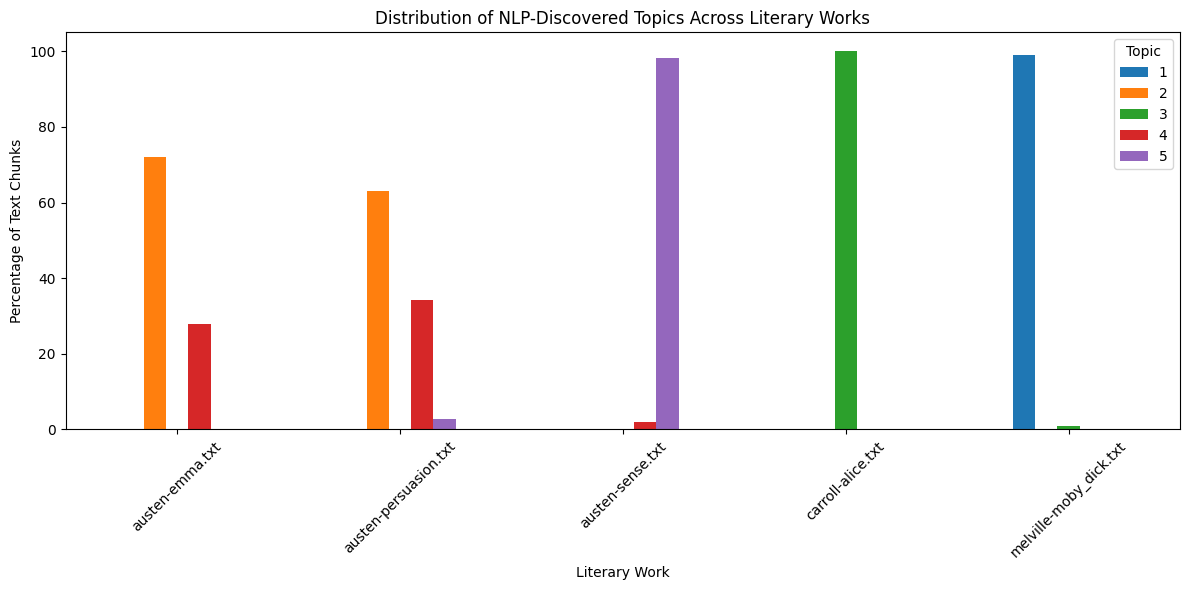

In [63]:
topic_distribution.plot(
    kind='bar',
    figsize=(12, 6)
)

plt.title("Distribution of NLP-Discovered Topics Across Literary Works")
plt.xlabel("Literary Work")
plt.ylabel("Percentage of Text Chunks")
plt.xticks(rotation=45)
plt.legend(title="Topic")
plt.tight_layout()
plt.show()